# 載入資料集與預處理

In [1]:
from keras.datasets import mnist

(x_train_image, y_train_label), (x_test_image, y_test_label) = mnist.load_data()

# reshape 為4維資料
x_train_image_4d = x_train_image.reshape(-1, 28, 28, 1).astype('float32')
x_test_image_4d = x_test_image.reshape(-1, 28, 28, 1).astype('float32')

# 標準化
x_train_normalize = x_train_image_4d / 255
x_test_normalize = x_test_image_4d / 255

# 標籤進行One-hot Encoding
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train_label)
y_test_onehot = to_categorical(y_test_label)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 建立模型

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input

model = Sequential([
    Input(shape=(28, 28, 1)),

    # 卷積層
    Conv2D(
        filters=32,
        kernel_size=(5,5),
        padding='same',
        activation='relu',
        name='conv1'
    ),
    # 池化層
    MaxPooling2D(pool_size=(2,2), name='pol1'),

    # 卷積層
    Conv2D(
        filters=64,
        kernel_size=(5,5),
        padding='same',
        activation='relu',
        name='conv2'
    ),
    # 池化層
    MaxPooling2D(pool_size=(2,2), name='pol2'),

    # 平坦層
    Flatten(name='flatten'),
    # 隱藏層
    Dense(128, activation='relu', name='hidden'),
    # 輸出層
    Dense(10, activation='softmax', name='output')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pol1 (MaxPooling2D)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pol2 (MaxPooling2D)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,922 (1.74 MB)

 Trainable params: 454,922 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.layers

[<Conv2D name=conv1, built=True>,
 <MaxPooling2D name=pol1, built=True>,
 <Conv2D name=conv2, built=True>,
 <MaxPooling2D name=pol2, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=hidden, built=True>,
 <Dense name=output, built=True>]

In [4]:
DISPLAY_LAYER = 4
# 取得前 4 層的輸出
output_layers = [layer.output for layer in model.layers[:DISPLAY_LAYER]]
output_layers

[<KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>,
 <KerasTensor shape=(None, 14, 14, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>,
 <KerasTensor shape=(None, 14, 14, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>,
 <KerasTensor shape=(None, 7, 7, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>]

In [5]:
from tensorflow.keras import models

DISPLAY_LAYER = 4
output_layers = [layer.output for layer in model.layers[:DISPLAY_LAYER]]

feature_map_model = models.Model(
    inputs=model.inputs,
    outputs=output_layers
)

feature_map_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pol1 (MaxPooling2D)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pol2 (MaxPooling2D)             │ (None, 7, 7, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

 Non-trainable params: 0 (0.00 B)

#  產生特徵圖

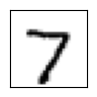

In [6]:
import matplotlib.pyplot as plt

def plot_image(image, img_size=1):
  fig = plt.gcf()
  fig.set_size_inches(img_size, img_size)
  plt.imshow(image, cmap='binary')
  plt.xticks([])
  plt.yticks([])
  plt.show()

IMG_ID = 0
plot_image(x_test_image[IMG_ID])

In [7]:
x_test_image[IMG_ID].shape

(28, 28)

In [8]:
input_4d_img = (x_test_image[IMG_ID].reshape(-1, 28, 28, 1).astype('float32')) / 255
input_4d_img.shape

(1, 28, 28, 1)

In [9]:
feature_maps = feature_map_model.predict(input_4d_img)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc'])

train_history = model.fit(
    x_train_normalize,
    y_train_onehot,
    validation_split=0.2,
    batch_size=200,
    epochs=10,
    verbose=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - acc: 0.9285 - loss: 0.2453 - val_acc: 0.9778 - val_loss: 0.0710
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9825 - loss: 0.0576 - val_acc: 0.9853 - val_loss: 0.0487
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.9882 - loss: 0.0379 - val_acc: 0.9880 - val_loss: 0.0395
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.9914 - loss: 0.0269 - val_acc: 0.9886 - val_loss: 0.0383
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.9924 - loss: 0.0247 - val_acc: 0.9887 - val_loss: 0.0400
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.9949 - loss: 0.0166 - val_acc: 0.9908 - val_loss: 0.0322
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.9957 - loss: 0.0133 - val_acc: 0.9904 - val_loss: 0.0356
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.9960 - loss: 0.0130 - val_acc: 0.9913 - val_loss: 0.0312
Epoch 9/10
240/24

In [19]:
feature_maps_trained = feature_map_model.predict(input_4d_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [10]:
# 顯示各層名稱
layer_names = []
for layer in feature_map_model.layers:
  layer_names.append(layer.name)
  print(layer.name)

input_layer
conv1
pol1
conv2
pol2


In [11]:
print(len(feature_maps))
for i in range(len(feature_maps)):
  print('layer', i, ' ', layer_names[i], ':', feature_maps[i].shape)

4
layer 0   input_layer : (1, 28, 28, 32)
layer 1   conv1 : (1, 14, 14, 32)
layer 2   pol1 : (1, 14, 14, 64)
layer 3   conv2 : (1, 7, 7, 64)


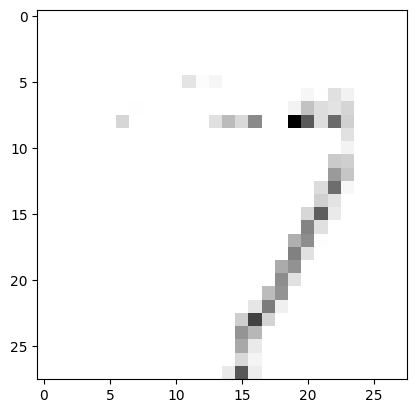

In [12]:
plt.imshow(feature_maps[0][0, :, :, 0], cmap='Greys')
plt.show()

# 顯示全部特徵圖

In [21]:
import math

def display_feature_maps(feature_maps, layer_names, idx, fig_width=10, n_cols=8, p_cmap='Greys'):
    print('layer', idx, layer_names[idx], feature_maps[idx].shape)

    n_feature_maps = feature_maps[idx].shape[3]
    n_rows = math.ceil(n_feature_maps / n_cols)

    fig = plt.gcf()
    fig.set_size_inches(fig_width, n_rows * 1.2)

    for i in range(n_feature_maps):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.imshow(feature_maps[idx][0, :, :, i], cmap=p_cmap)

    plt.show()

# 訓練前後比較

layer 0 input_layer (1, 28, 28, 32)


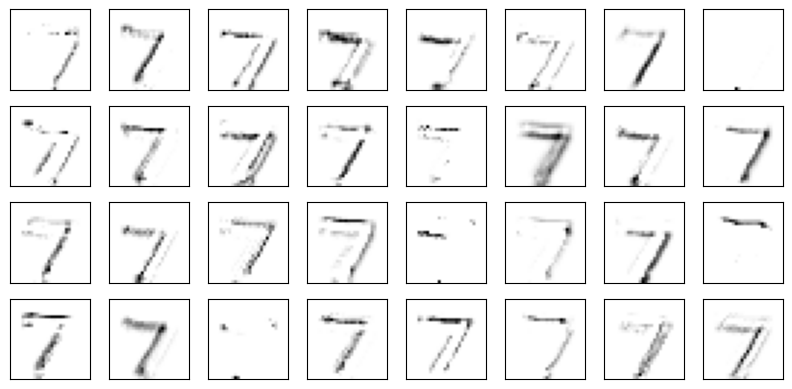

In [22]:
# 訓練前
# 顯示第0層(卷積層1)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=0)

layer 0 input_layer (1, 28, 28, 32)


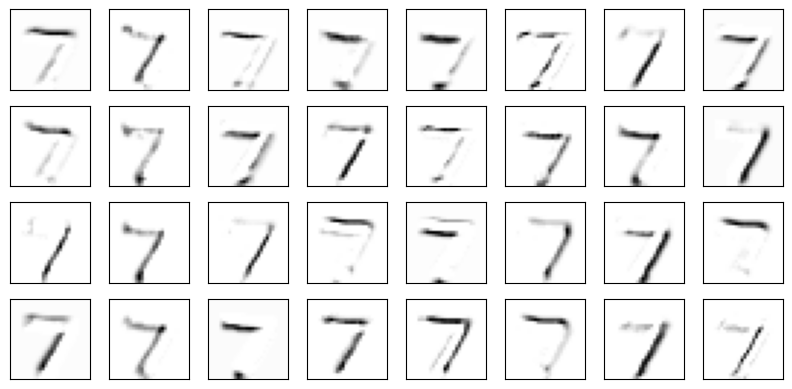

In [23]:
# 訓練後
# 顯示第0層(卷積層1)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=0)



*   訓練前無法有效提取「橫」與「斜」的特徵
*   訓練後則改善許多



layer 1 conv1 (1, 14, 14, 32)


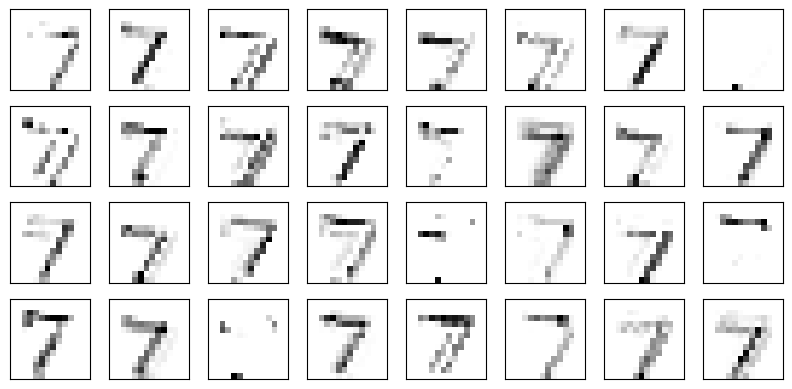

In [24]:
# 訓練前
# 顯示第1層(池化層1)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=1)

layer 1 conv1 (1, 14, 14, 32)


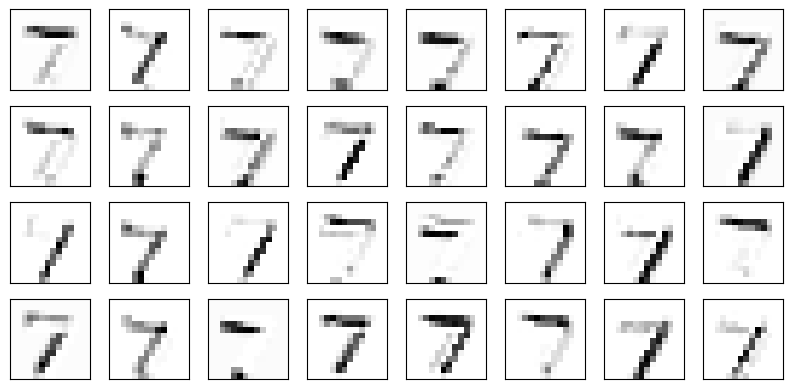

In [25]:
# 訓練後
# 顯示第1層(池化層1)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=1)



*   訓練前無法有效提取特徵(特徵模糊)
*   訓練後則改善許多(特徵清楚)




layer 2 pol1 (1, 14, 14, 64)


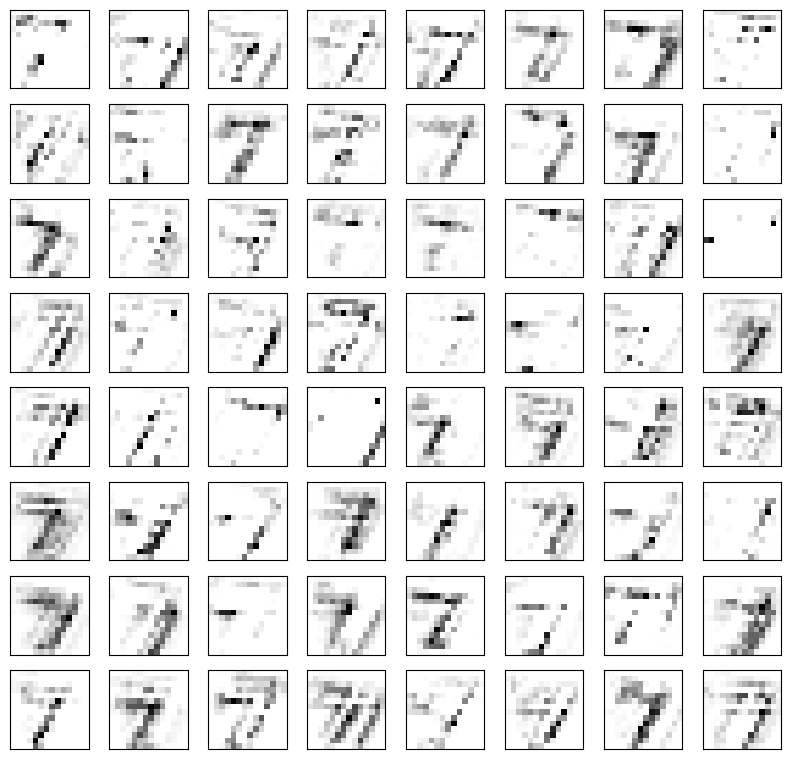

layer 2 pol1 (1, 14, 14, 64)


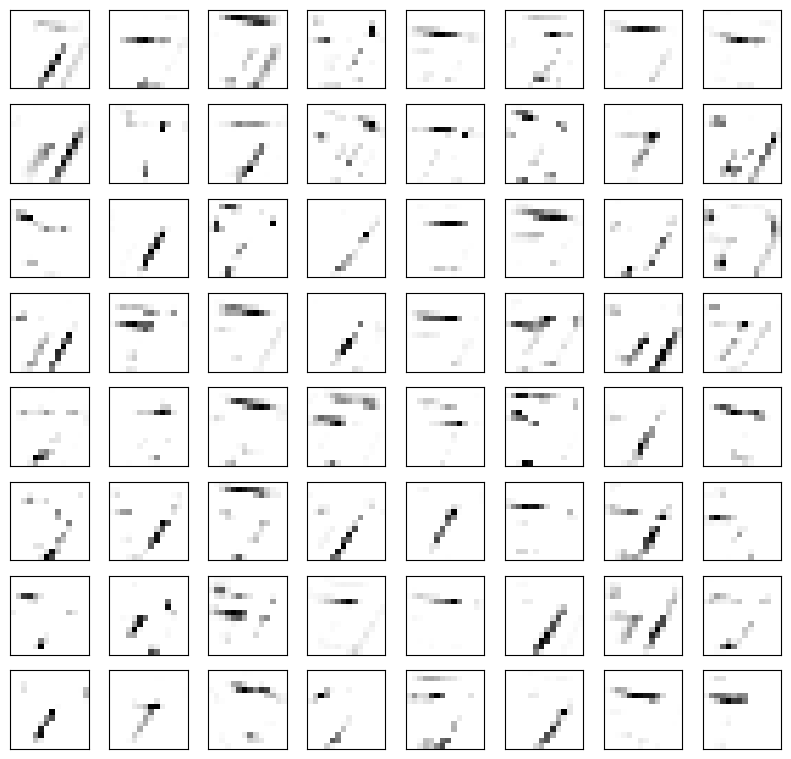

In [26]:
# 訓練前
# 顯示第3層(卷積層2)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=2)

# 訓練後
# 顯示第3層(卷積層2)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=2)

*   訓練前無法有效提取「橫」與「斜」的特徵(特徵模糊)
*   訓練後則改善許多(特徵清楚)

layer 3 conv2 (1, 7, 7, 64)


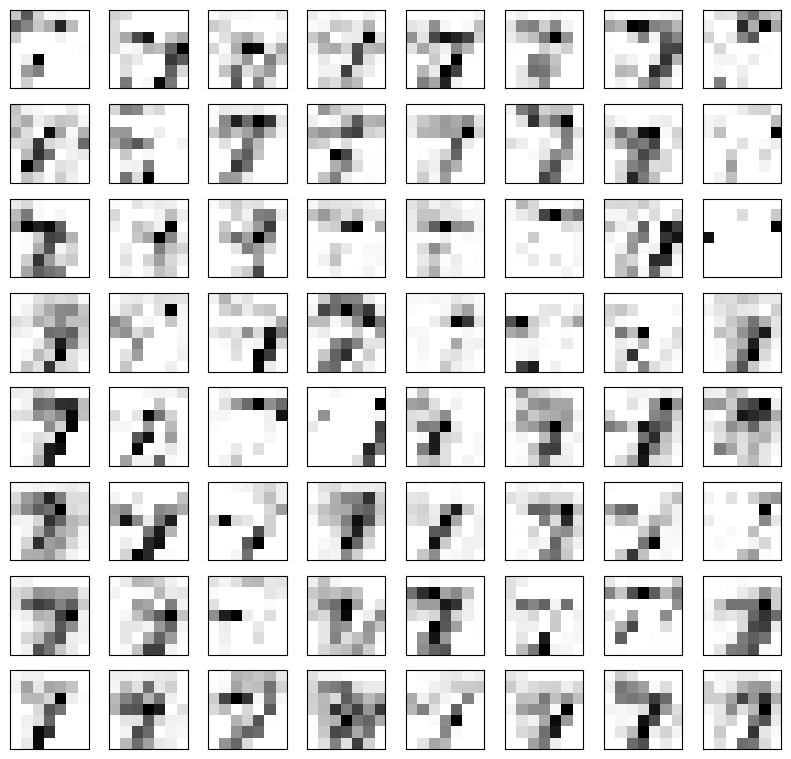

layer 3 conv2 (1, 7, 7, 64)


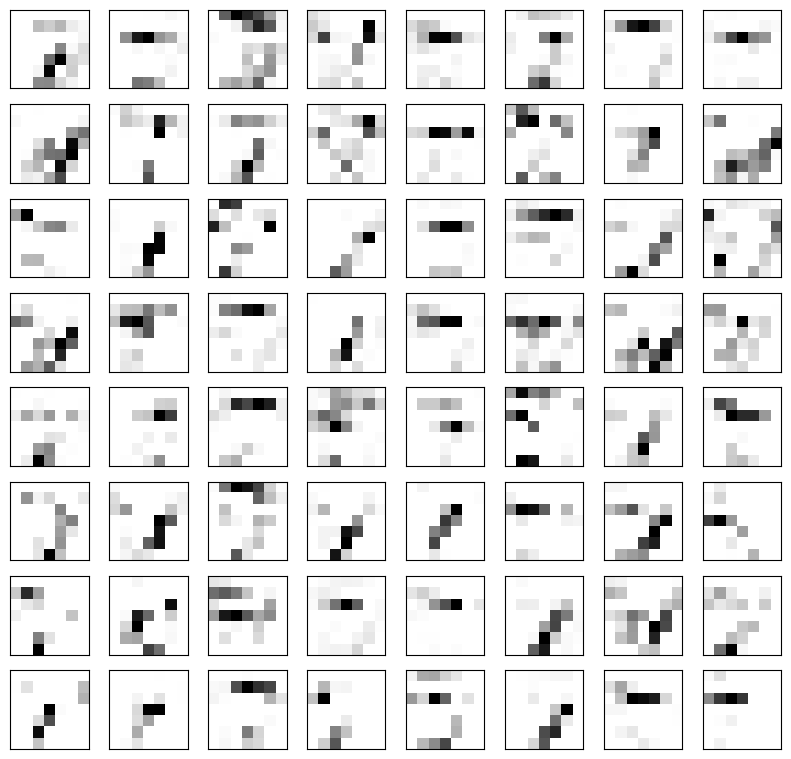

In [28]:
# 訓練前
# 顯示第4層(池化層2)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=3)

# 訓練後
# 顯示第4層(池化層2)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=3)

*   訓練前無法有效提取「橫」與「斜」的特徵(特徵模糊)
*   訓練後則改善許多(特徵清楚)